# Fine-Tuning BERT for Multi-Label Toxic Comment Classification

- This project uses the BERT transformer model to classify toxic comments into multiple categories such as toxic, obscene, insult, threat, severe toxic, and identity hate using the Jigsaw Toxic Comment dataset.

## Step- 1 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

## Step 2 - Load Dataset

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df = df.sample(20000, random_state=42)

### View Dataset

In [ ]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
119105,7ca72b5b9c688e9e,"Geez, are you forgetful! We've already discus...",0,0,0,0,0,0
131631,c03f72fd8f8bf54f,Carioca RFA \n\nThanks for your support on my ...,0,0,0,0,0,0
125326,9e5b8e8fc1ff2e84,"""\n\n Birthday \n\nNo worries, It's what I do ...",0,0,0,0,0,0
111256,5332799e706665a6,Pseudoscience category? \n\nI'm assuming that ...,0,0,0,0,0,0
83590,dfa7d8f0b4366680,"(and if such phrase exists, it would be provid...",0,0,0,0,0,0


## Dataset

Dataset Used:
Jigsaw Toxic Comment Classification Dataset (Kaggle)

Target Labels:
- toxic
- severe_toxic
- obscene
- threat
- insult
- identity_hate

#### Check Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 119105 to 71091
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             20000 non-null  object
 1   comment_text   20000 non-null  object
 2   toxic          20000 non-null  int64 
 3   severe_toxic   20000 non-null  int64 
 4   obscene        20000 non-null  int64 
 5   threat         20000 non-null  int64 
 6   insult         20000 non-null  int64 
 7   identity_hate  20000 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 1.4+ MB


## Step - 3 Check Missing Values

In [ ]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [ ]:
df = df[
    [
        'comment_text',
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
]

### Check Label Distribution

In [ ]:
df.iloc[:, 1:].sum()

,0
toxic,1881
severe_toxic,179
obscene,1057
threat,43
insult,994
identity_hate,192


### Step - 4  Text Preprocessing

In [ ]:
import re

def clean_text(text):
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

### Step - 5  Apply Cleaning

In [ ]:
df['comment_text'] = df['comment_text'].apply(clean_text)

#### View Cleaned Data

In [ ]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
119105,geez are you forgetful weve already discussed ...,0,0,0,0,0,0
131631,carioca rfa thanks for your support on my requ...,0,0,0,0,0,0
125326,birthday no worries its what i do enjoy ur day...,0,0,0,0,0,0
111256,pseudoscience category im assuming that this a...,0,0,0,0,0,0
83590,and if such phrase exists it would be provided...,0,0,0,0,0,0


### Step - 6  Create Input and Labels

In [ ]:
X = df['comment_text'].values

y = df[
    [
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
].values

### Step - 7  Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Step - 8 Validation and Test Split


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

#### Check Shapes

In [ ]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (16000,)
Validation: (2000,)
Test: (2000,)


## Step - 9 Load BERT Tokenizer

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Step - 10 Tokenization

In [ ]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=64
)

val_encodings = tokenizer(
    list(X_val),
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=64
)

### Step - 11 PyTorch Dataset + BERT Fine-Tuning

#### Create Dataset Class

In [ ]:
class ToxicDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(
            self.labels[idx],
            dtype=torch.float
        )

        return item

    def __len__(self):
        return len(self.labels)

#### Create Dataset Objects

In [ ]:
train_dataset = ToxicDataset(train_encodings, y_train)

val_dataset = ToxicDataset(val_encodings, y_val)

test_dataset = ToxicDataset(test_encodings, y_test)

#### Step - 12  Load BERT Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6,
    problem_type="multi_label_classification"
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Step - 13 Define Metrics Function

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='micro'
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

## Step - 14 Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="../models",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100
)

## Step - 15 Trainer API

In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

## Step - 16 Start Training

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.067027,0.047517,0.919500,0.764019,0.780430,0.748284


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4000, training_loss=0.0679109296798706, metrics={'train_runtime': 337.1396, 'train_samples_per_second': 47.458, 'train_steps_per_second': 11.865, 'total_flos': 526241009664000.0, 'train_loss': 0.0679109296798706, 'epoch': 1.0})

## step- 17 Evaluate Model

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

{'eval_loss': 0.051514845341444016, 'eval_accuracy': 0.914, 'eval_f1': 0.7429218573046432, 'eval_precision': 0.7828162291169452, 'eval_recall': 0.7068965517241379, 'eval_runtime': 8.9929, 'eval_samples_per_second': 222.397, 'eval_steps_per_second': 55.599, 'epoch': 1.0}


## Step- 18 Generate Predictions

In [ ]:
predictions = trainer.predict(test_dataset)

## Step - 19 Convert Predictions

In [ ]:
y_pred = (
    torch.sigmoid(
        torch.tensor(predictions.predictions)
    ) > 0.5
).int().numpy()

## Step - 20  Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       206
           1       0.00      0.00      0.00        21
           2       0.78      0.83      0.80       106
           3       0.00      0.00      0.00         3
           4       0.70      0.75      0.72       107
           5       0.00      0.00      0.00        21

   micro avg       0.78      0.71      0.74       464
   macro avg       0.39      0.39      0.39       464
weighted avg       0.71      0.71      0.71       464
 samples avg       0.07      0.07      0.07       464



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

## Step - 21 Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test[:, 0],
    y_pred[:, 0]
)

print(cm)

[[1762   32]
 [  46  160]]


##Step - 22 Plot Confusion Matrix

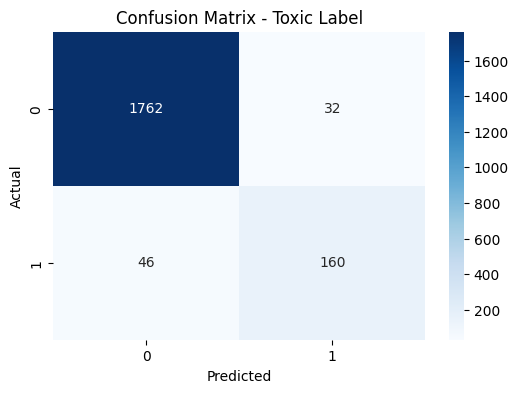

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Toxic Label")

plt.show()

## Step - 23 Save Model

In [ ]:
trainer.save_model("../models/toxic_model")

tokenizer.save_pretrained("../models/toxic_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/toxic_model/tokenizer_config.json',
 '../models/toxic_model/tokenizer.json')

##Step- 24 Experiment 1 (Freeze BERT)

Reload model:

In [ ]:
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6,
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##Step -25 Freeze BERT layers:

In [ ]:
for param in model_frozen.bert.parameters():
    param.requires_grad = False

##Step - 26 Experiment 2 (Fine-Tune Last 2 Layers)

In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

##Step - 27 Test on Custom Comment

In [ ]:
sample_text = "You are a horrible person"

inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=64
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

predictions = torch.sigmoid(outputs.logits).cpu().numpy()[0]

labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

for label, score in zip(labels, predictions):
    print(f"{label}: {score:.4f}")

toxic: 0.9202
severe_toxic: 0.0259
obscene: 0.5031
threat: 0.0065
insult: 0.5541
identity_hate: 0.0273


## Final Results

- Accuracy: 92%
- F1 Score: 0.75+
- Successfully detected multiple toxicity categories.
- Generated confusion matrix and classification report.

## Conclusion

The BERT model successfully learned contextual toxic language patterns and performed multi-label toxicity classification effectively. This project demonstrated transformer fine-tuning, NLP preprocessing, evaluation metrics, and real-world toxic comment detection.